In [1]:
import cobrabox as cb
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [30]:
from pathlib import Path

PROJECT_DIR = Path(".")
cb.set_dataset_dir(PROJECT_DIR / "data", persist=False)

In [31]:

SEGMENT_DURATION = 3.0  # seconds
N_SEGMENTS = 20
rng = np.random.default_rng(42)

BANDS = {
    'delta':        (2, 4),
    'theta':        (5, 7),
    'alpha':        (8, 12),
    'beta':         (15, 29),
    'low_gamma':    (30, 59),
    'high_gamma':   (60, 79),
    'ripples':      (80, 249),
    'fast_ripples': (250, 500),
}

For the full dataset loading (takes up all the memory!)

In [3]:
# cb.set_dataset_dir("/home/pidnebesna/Documents/Projects/Other/cobrabox/data/")
# # ds = cb.load_dataset("zurich_ieeg", subset=["sub-01"])
# ds = cb.load_dataset("zurich_ieeg", accept=True)

In [33]:
import csv
import re

def parse_channel_list(raw):
    if not raw or raw.strip() in ("None", "No channels were removed", ""):
        return []
    return [
        line.strip().strip("'")
        for line in raw.split('\n')
        if line.strip().strip("'") and '-' in line
    ]

def load_patient_info(path=None):
    if path is None:
        path = PROJECT_DIR / "data" / "Patient_Info_Zurich_Annicka.csv"
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=';', quotechar='"')
        rows = list(reader)

    result = {}
    for row in rows[1:]:  # skip header
        if len(row) < 6:
            continue
        m = re.match(r'Patient (\d+)', row[0].strip())
        if not m:
            continue
        sub_id = f"sub-{int(m.group(1)):02d}"
        result[sub_id] = {
            "outcome": row[1].strip(),           # e.g. "ILAE1"
            "resected": parse_channel_list(row[3]),
            "pipeline_exclusions": parse_channel_list(row[5]),
        }
    return result

# patient_info = load_patient_info()
# patient_info["sub-01"]["outcome"]             → "ILAE1"
# patient_info["sub-01"]["resected"]            → ['AHR1-AHR2', ...]
# patient_info["sub-01"]["pipeline_exclusions"] → ['AHL4-AHL5', ...]

In [34]:
from scipy.signal import iirnotch, filtfilt
import xarray as xr

def notch_filter(da, freq=50.0, q=30.0, fs=None):
    b, a = iirnotch(freq, q, fs)
    return xr.apply_ufunc(
        lambda x: filtfilt(b, a, x, axis=0),
        da,
    )

In [35]:
# Build pool of (run_idx, start_sample) pairs
def build_segment_pool(ds):
    pool = []
    for run_idx, item in enumerate(ds):
        fs = item.sampling_rate
        n_samples = item.data.sizes['time']  # time is first dim
        seg_len = int(fs * SEGMENT_DURATION)
        n_segments = n_samples // seg_len
        for seg_idx in range(n_segments):
            pool.append((run_idx, seg_idx * seg_len))

    # Sample N_SEGMENTS
    chosen = rng.choice(len(pool), size=N_SEGMENTS, replace=False)
    segments = [pool[i] for i in chosen]
    return segments


In [36]:
def get_valid_pairs(item, subject_id, patient_info):
    available = set(item.data.coords['space'].values)
    excluded = set(item.extra.get('excluded_channels', []))
    pipeline_exclusions = set(patient_info.get(subject_id, {}).get("pipeline_exclusions", []))

    # Check for missing monopolar channels
    monopolar = list(dict.fromkeys(
        ch for pair in item.extra['all_channels'] for ch in pair.split('-')
    ))
    missing = [ch for ch in monopolar if ch not in available]
    if missing:
        print(f"[{subject_id}] Missing monopolar channels: {missing}")

    valid_pairs = [
        pair for pair in item.extra['all_channels']
        if pair not in pipeline_exclusions
        and all(ch in available and ch not in excluded for ch in pair.split('-'))
    ]

    # Check resected channels are covered by valid pairs
    resected = set(patient_info.get(subject_id, {}).get("resected", []))
    missing_resected = resected - set(valid_pairs)
    if missing_resected:
        print(f"[{subject_id}] WARNING: resected channels not in valid pairs: {missing_resected}")

    return valid_pairs

def apply_bipolar_montage(da, valid_pairs):
    return xr.concat([
        (da.sel(space=a) - da.sel(space=b)).assign_coords(space=f"{a}-{b}")
        for a, b in (pair.split('-') for pair in valid_pairs)
    ], dim='space')

def extract_segments(ds, subject_id, patient_info):
    segments = build_segment_pool(ds)
    valid_pairs = get_valid_pairs(ds[0], subject_id, patient_info)

    segments_data = []
    for run_idx, start_sample in segments:
        item = ds[run_idx]
        seg_len = int(item.sampling_rate * SEGMENT_DURATION)
        segment_da = item.data.isel(time=slice(start_sample, start_sample + seg_len))
        segment_da = notch_filter(segment_da, fs=item.sampling_rate)
        segment_da = apply_bipolar_montage(segment_da, valid_pairs)
        segments_data.append(cb.SignalData.from_xarray(
            segment_da,
            sampling_rate=item.sampling_rate,
            extra={"run_idx": run_idx, "start_sample": start_sample},
        ))
    return cb.Dataset(segments_data)


In [56]:
SEGMENTS_DIR     = Path("data/segments")
CONNECTIVITY_DIR = Path("data/connectivity")

def save_segments(segments_dataset, subject_id, segments_dir=SEGMENTS_DIR):
    segments_dir.mkdir(exist_ok=True)
    n_time = segments_dataset[0].data.sizes['time']
    common_time = np.arange(n_time)
    da = xr.concat(
        [seg.data.assign_coords(time=common_time) for seg in segments_dataset],
        dim='segment',
    )
    da = da.assign_coords(segment=np.arange(len(segments_dataset)))
    da.attrs['sampling_rate'] = segments_dataset[0].sampling_rate
    da.to_netcdf(segments_dir / f"{subject_id}_segments.nc")

def load_segments(subject_id, segments_dir=SEGMENTS_DIR):
    da = xr.load_dataarray(segments_dir / f"{subject_id}_segments.nc")
    sr = da.attrs['sampling_rate']
    return cb.Dataset([
        cb.SignalData.from_xarray(
            da.isel(segment=i).drop_vars('segment'),
            sampling_rate=sr,
            subjectID=subject_id,
        )
        for i in range(da.sizes['segment'])
    ])

def save_connectivity(avg_pdc, subject_id, connectivity_dir=CONNECTIVITY_DIR):
    connectivity_dir.mkdir(exist_ok=True)
    da = xr.concat(
        [mat.expand_dims('band').assign_coords(band=[band_name])
         for band_name, mat in avg_pdc.items()],
        dim='band',
    )
    da.to_netcdf(connectivity_dir / f"{subject_id}_connectivity.nc")

def load_connectivity(subject_id, connectivity_dir=CONNECTIVITY_DIR):
    da = xr.load_dataarray(connectivity_dir / f"{subject_id}_connectivity.nc")
    return {str(band): da.sel(band=band).drop_vars('band')
            for band in da.coords['band'].values}

In [38]:
# Run once to extract segments from the full dataset and save them.
# Skips subjects that already have a saved file.
subjects = [f"sub-{i:02d}" for i in range(1, 21)]
patient_info = load_patient_info()

for subject_id in subjects:
    out_path = SEGMENTS_DIR / f"{subject_id}_segments.nc"
    if out_path.exists():
        print(f"{subject_id}: already saved, skipping")
        continue
    print(f"{subject_id}: extracting...")
    ds = cb.load_dataset("zurich_ieeg", subset=[subject_id])
    segs = extract_segments(ds, subject_id, patient_info)
    del ds
    save_segments(segs, subject_id)
    print(f"{subject_id}: saved {len(segs)} segments → {out_path}")

sub-01: extracting...


/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)


[sub-01] Missing monopolar channels: ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8']
sub-01: saved 20 segments → data/segments/sub-01_segments.nc
sub-02: extracting...
sub-02: saved 20 segments → data/segments/sub-02_segments.nc
sub-03: extracting...


/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)


sub-03: saved 20 segments → data/segments/sub-03_segments.nc
sub-04: extracting...
[sub-04] Missing monopolar channels: ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8', 'AHR1', 'AHR2', 'AHR3', 'AHR4', 'AHR5', 'AHR6', 'AHR7', 'AHR8', 'ECL1', 'ECL2', 'ECL3', 'ECL4', 'ECL5', 'ECL6', 'ECL7', 'ECL8', 'ECR1', 'ECR2', 'ECR3', 'ECR4', 'ECR5', 'ECR6', 'ECR7', 'ECR8', 'PHL1', 'PHL2', 'PHL3', 'PHL4', 'PHL5', 'PHL6', 'PHL7', 'PHL8', 'PHR1', 'PHR2', 'PHR3', 'PHR4', 'PHR5', 'PHR6', 'PHR7', 'PHR8']
[sub-04] WARNING: resected channels not in valid pairs: {'AHR1-AHR2', 'PHR2-PHR3', 'AHR3-AHR4', 'AHR2-AHR3', 'ECR2-ECR3', 'PHR1-PHR2', 'PHR3-PHR4', 'ECR1-ECR2', 'ECR3-ECR4'}
sub-04: saved 20 segments → data/segments/sub-04_segments.nc
sub-05: extracting...
sub-05: saved 20 segments → data/segments/sub-05_segments.nc
sub-06: extracting...


...

sub-13: saved 20 segments → data/segments/sub-13_segments.nc
sub-14: extracting...
sub-14: saved 20 segments → data/segments/sub-14_segments.nc
sub-15: extracting...


/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Omitted 15128 annotation(s) that were outside data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)
/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Omitted 15139 annotation(s) that were outside data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)
/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Omitted 26738 annotation(s) that were outside data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)
/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Omitted 25556 annotation(s) that were outside data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)
/home/pidnebesna/Documents/Projects/Other/cobrabox/s

[sub-15] WARNING: resected channels not in valid pairs: {'TBAL2-3', 'TLL1-2', 'TLL9-10', 'TBAL3-4'}
sub-15: saved 20 segments → data/segments/sub-15_segments.nc
sub-16: extracting...


/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)


sub-16: saved 20 segments → data/segments/sub-16_segments.nc
sub-17: extracting...
sub-17: saved 20 segments → data/segments/sub-17_segments.nc
sub-18: extracting...
sub-18: saved 20 segments → data/segments/sub-18_segments.nc
sub-19: extracting...
sub-19: saved 20 segments → data/segments/sub-19_segments.nc
sub-20: extracting...
sub-20: saved 20 segments → data/segments/sub-20_segments.nc


In [40]:
rc = cb.feature.ReciprocalConnectivity(connectivity='pdc', freq_band=None)
patient_info = load_patient_info()

values_per_band = {}
rc_resected = {}
rc_non_resected = {}
for band_name in BANDS.keys():
    rc_resected[band_name] = {}
    rc_non_resected[band_name] = {}

In [49]:
subject_id = "sub-01"
segments_dataset = load_segments(subject_id)
pdc = cb.feature.PartialDirectedCoherence(n_freqs=1000)
results = cb.Dataset([pdc.apply(item) for item in tqdm(segments_dataset, desc="Computing PDC", total=len(segments_dataset))])
pdc_mean = xr.concat([item.data for item in results], dim='segment').mean(dim='segment')
avg_pdc = {
    band_name: pdc_mean.sel(frequency=slice(low, high)).mean(dim='frequency')
    for band_name, (low, high) in BANDS.items()
}

rc_per_band = {
    band_name: rc.apply(cb.Data.from_xarray(avg_pdc[band_name]))
    for band_name in BANDS.keys()
}

channels = rc_per_band[next(iter(BANDS))].data.coords['space'].values
resected = set(patient_info[subject_id]['resected'])
resected_mask = np.array([ch in resected for ch in channels])

values_per_band[subject_id] = {
    band_name: rc_per_band[band_name].data.values
    for band_name in BANDS.keys()
}

for band_name in BANDS.keys():
    rc_resected[band_name][subject_id] = values_per_band[subject_id][band_name][resected_mask]
    rc_non_resected[band_name][subject_id] = values_per_band[subject_id][band_name][~resected_mask]

print(f"  resected: {rc_resected[band_name][subject_id].mean():.4f}  non-resected: {rc_non_resected[band_name][subject_id].mean():.4f}")

Computing PDC: 100%|██████████| 20/20 [03:10<00:00,  9.54s/it]

  resected: -0.0027  non-resected: 0.0022


In [57]:
rc = cb.feature.ReciprocalConnectivity(connectivity='pdc', freq_band=None)
patient_info = load_patient_info()

values_per_band = {}
rc_resected = {}
rc_non_resected = {}
for band_name in BANDS.keys():
    rc_resected[band_name] = {}
    rc_non_resected[band_name] = {}

for subject_id in subjects:
    print(f"Subject: {subject_id}")

    conn_path = CONNECTIVITY_DIR / f"{subject_id}_connectivity.nc"
    if conn_path.exists():
        print(f"  loading connectivity from disk")
        avg_pdc = load_connectivity(subject_id)
    else:
        segments_dataset = load_segments(subject_id)
        pdc = cb.feature.PartialDirectedCoherence(n_freqs=1000)
        results = cb.Dataset([pdc.apply(item) for item in tqdm(segments_dataset, desc="Computing PDC", total=len(segments_dataset))])
        pdc_mean = xr.concat([item.data for item in results], dim='segment').mean(dim='segment')
        avg_pdc = {
            band_name: pdc_mean.sel(frequency=slice(low, high)).mean(dim='frequency')
            for band_name, (low, high) in BANDS.items()
        }
        save_connectivity(avg_pdc, subject_id)
        print(f"  saved connectivity to {conn_path}")

    rc_per_band = {
        band_name: rc.apply(cb.Data.from_xarray(avg_pdc[band_name]))
        for band_name in BANDS.keys()
    }

    channels = rc_per_band[next(iter(BANDS))].data.coords['space'].values
    resected = set(patient_info[subject_id]['resected'])
    resected_mask = np.array([ch in resected for ch in channels])

    values_per_band[subject_id] = {
        band_name: rc_per_band[band_name].data.values
        for band_name in BANDS.keys()
    }

    for band_name in BANDS.keys():
        rc_resected[band_name][subject_id] = values_per_band[subject_id][band_name][resected_mask]
        rc_non_resected[band_name][subject_id] = values_per_band[subject_id][band_name][~resected_mask]

    print(f"  resected: {rc_resected[band_name][subject_id].mean():.4f}  non-resected: {rc_non_resected[band_name][subject_id].mean():.4f}")

Subject: sub-01


Computing PDC: 100%|██████████| 20/20 [01:22<00:00,  4.10s/it]


  saved connectivity to data/connectivity/sub-01_connectivity.nc
  resected: -0.0027  non-resected: 0.0022
Subject: sub-02


Computing PDC: 100%|██████████| 20/20 [01:58<00:00,  5.91s/it]


  saved connectivity to data/connectivity/sub-02_connectivity.nc
  resected: 0.0009  non-resected: -0.0009
Subject: sub-03


...

  saved connectivity to data/connectivity/sub-18_connectivity.nc
  resected: -0.0198  non-resected: 0.0038
Subject: sub-19


Computing PDC: 100%|██████████| 20/20 [05:44<00:00, 17.23s/it]


  saved connectivity to data/connectivity/sub-19_connectivity.nc
  resected: 0.0176  non-resected: -0.0026
Subject: sub-20


Computing PDC: 100%|██████████| 20/20 [00:59<00:00,  2.96s/it]

  saved connectivity to data/connectivity/sub-20_connectivity.nc
  resected: 0.0025  non-resected: -0.0013


In [58]:
from scipy.stats import wilcoxon
import pandas as pd

# Per-subject mean RC for resected and non-resected channels
records = []
for band_name in BANDS.keys():
    for subject_id in subjects:
        r = rc_resected[band_name].get(subject_id)
        nr = rc_non_resected[band_name].get(subject_id)
        if r is None or nr is None or len(r) == 0 or len(nr) == 0:
            continue
        records.append({
            "subject":      subject_id,
            "band":         band_name,
            "rc_resected":  r.mean(),
            "rc_non_resected": nr.mean(),
            "diff":         r.mean() - nr.mean(),
        })

df = pd.DataFrame(records)
df.head(10)

,subject,band,rc_resected,rc_non_resected,diff
0,sub-01,delta,0.010319,-0.008443,0.018762
1,sub-02,delta,-0.002440,0.002440,-0.004880
2,sub-03,delta,-0.009822,0.039290,-0.049112
3,sub-04,delta,0.002524,-0.002524,0.005049
4,sub-05,delta,0.002513,-0.002513,0.005026
5,sub-06,delta,0.003108,-0.003108,0.006216
6,sub-07,delta,0.004171,-0.004171,0.008342
7,sub-08,delta,0.005400,-0.005400,0.010800
8,sub-09,delta,-0.015746,0.015746,-0.031493
9,sub-10,delta,0.044436,-0.003921,0.048356


In [59]:
# Wilcoxon signed-rank test per band (one-sided: resected > non-resected)
stats_rows = []
for band_name in BANDS.keys():
    band_df = df[df['band'] == band_name]
    res  = band_df['rc_resected'].values
    nres = band_df['rc_non_resected'].values
    if len(res) < 5:
        continue
    stat, p = wilcoxon(res, nres, alternative='greater')
    stats_rows.append({
        "band":        band_name,
        "n_subjects":  len(res),
        "mean_diff":   (res - nres).mean(),
        "median_diff": np.median(res - nres),
        "W":           stat,
        "p_value":     p,
    })

stats_df = pd.DataFrame(stats_rows).set_index('band')
stats_df['significant'] = stats_df['p_value'] < 0.05
print(stats_df.to_string())

              n_subjects  mean_diff  median_diff      W   p_value  significant
band                                                                          
delta                 19   0.008877     0.005049  139.0  0.039938         True
theta                 19   0.009838     0.003830  131.0  0.078201        False
alpha                 19   0.010642     0.004307  132.0  0.072344        False
beta                  19   0.011162     0.007127  145.0  0.022280         True
low_gamma             19   0.013875     0.005469  162.0  0.002665         True
high_gamma            19   0.015497     0.003595  166.0  0.001419         True
ripples               19   0.014424     0.003604  156.0  0.006180         True
fast_ripples          19   0.012563     0.004902  151.0  0.011494         True


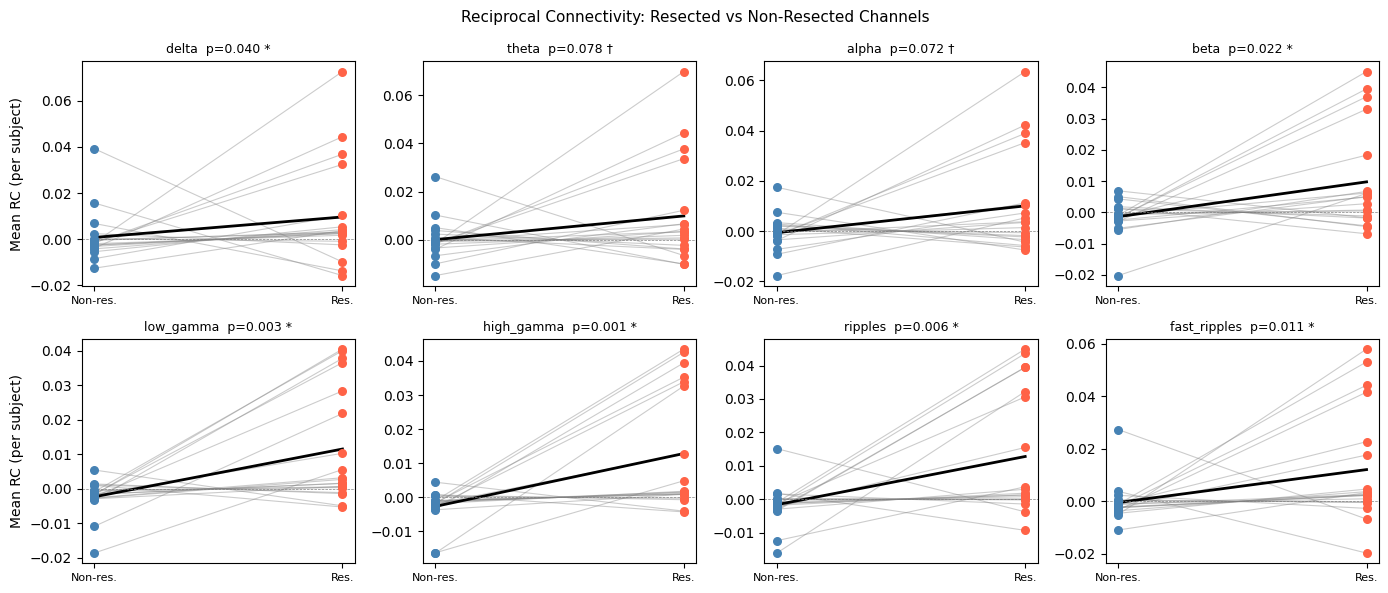

In [60]:
band_names = list(BANDS.keys())
n_bands = len(band_names)
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for ax, band_name in zip(axes, band_names):
    band_df = df[df['band'] == band_name]
    res  = band_df['rc_resected'].values
    nres = band_df['rc_non_resected'].values

    # Paired lines
    for r, nr in zip(res, nres):
        ax.plot([0, 1], [nr, r], color='gray', alpha=0.4, linewidth=0.8)

    ax.scatter([0] * len(nres), nres, color='steelblue', zorder=3, s=30, label='Non-resected')
    ax.scatter([1] * len(res),  res,  color='tomato',    zorder=3, s=30, label='Resected')
    ax.plot([0, 1], [nres.mean(), res.mean()], color='black', linewidth=2)

    p = stats_df.loc[band_name, 'p_value']
    sig = '*' if p < 0.05 else ('†' if p < 0.1 else '')
    ax.set_title(f"{band_name}  p={p:.3f} {sig}", fontsize=9)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-res.', 'Res.'], fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[0].set_ylabel('Mean RC (per subject)')
axes[4].set_ylabel('Mean RC (per subject)')
fig.suptitle('Reciprocal Connectivity: Resected vs Non-Resected Channels', fontsize=11)
plt.tight_layout()
plt.show()